In [1]:
1+1

2

In [2]:
!pip install pybaseball

In [3]:
from pybaseball import playerid_lookup

playerid_lookup("rodriguez", "bradgley", fuzzy=True)



ModuleNotFoundError: No module named 'pybaseball'

In [4]:
import sys
!{sys.executable} -m pip install pybaseball

  Using cached pybaseball-2.2.7-py3-none-any.whl.metadata (11 kB)
Using cached pybaseball-2.2.7-py3-none-any.whl (426 kB)


In [7]:
from pybaseball import playerid_lookup

playerid_lookup("rodriguez", "bradgley", fuzzy=True)

,name_last,name_first,key_mlbam,key_retro,key_bbref,key_fangraphs,mlb_played_first,mlb_played_last
0,rodriguez,bradgley,699134,rodrb001,rodribr01,29107,2025.0,2026.0


In [8]:
from pybaseball import statcast_pitcher

data = statcast_pitcher("2026-03-01", "2026-06-27", 699134)

print(data.shape)

Gathering Player Data
(681, 119)


In [9]:
data["pitch_type"].value_counts()

pitch_type
CH    276
SI    201
FF    142
SL     46
FC     15
Name: count, dtype: int64

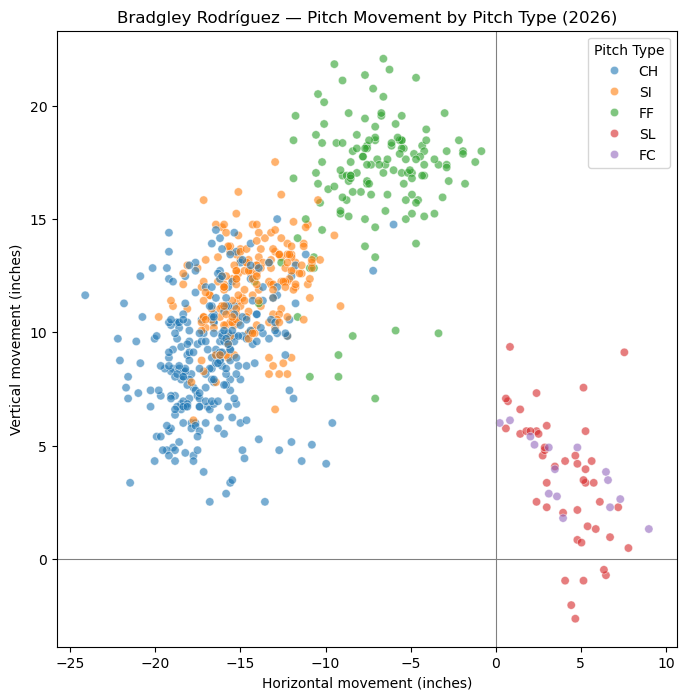

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Statcast stores movement in feet; multiply by 12 to get inches (easier to read)
data["pfx_x_inches"] = data["pfx_x"] * 12
data["pfx_z_inches"] = data["pfx_z"] * 12

plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=data,
    x="pfx_x_inches",
    y="pfx_z_inches",
    hue="pitch_type",
    alpha=0.6
)
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.xlabel("Horizontal movement (inches)")
plt.ylabel("Vertical movement (inches)")
plt.title("Bradgley Rodríguez — Pitch Movement by Pitch Type (2026)")
plt.legend(title="Pitch Type")
plt.show()

In [12]:
swings = ["foul", "hit_into_play", "swinging_strike", "swinging_strike_blocked", "foul_tip"]
whiffs = ["swinging_strike", "swinging_strike_blocked", "foul_tip"]

data["is_swing"] = data["description"].isin(swings)
data["is_whiff"] = data["description"].isin(whiffs)

summary = data.groupby("pitch_type").agg(pitches=("pitch_type", "count"), swings=("is_swing", "sum"), whiffs=("is_whiff", "sum"))

summary["whiff_rate"] = (summary["whiffs"] / summary["swings"] * 100).round(1)
summary["usage_%"] = (summary["pitches"] / summary["pitches"].sum() * 100).round(1)

summary = summary.sort_values("usage_%", ascending=False)
print(summary)


            pitches  swings  whiffs  whiff_rate  usage_%
pitch_type                                              
CH              276     149      61        40.9     40.6
SI              201      92      12        13.0     29.6
FF              142      63      18        28.6     20.9
SL               46      22       8        36.4      6.8
FC               15       7       4        57.1      2.2


In [13]:
import pandas as pd

# Pull his 2025 season
data_2025 = statcast_pitcher("2025-03-01", "2025-11-01", 699134)

# Stack 2025 + 2026 into one combined dataset
combined = pd.concat([data_2025, data], ignore_index=True)

print("2025 pitches:", data_2025.shape[0])
print("2026 pitches:", data.shape[0])
print("Combined:", combined.shape[0])

Gathering Player Data
2025 pitches: 150
2026 pitches: 681
Combined: 831


In [14]:
combined["is_swing"] = combined["description"].isin(swings)
combined["is_whiff"] = combined["description"].isin(whiffs)

summary_all = combined.groupby("pitch_type").agg(pitches=("pitch_type", "count"), swings=("is_swing", "sum"), whiffs=("is_whiff", "sum"))

summary_all["whiff_rate"] = (summary_all["whiffs"] / summary_all["swings"] * 100).round(1)
summary_all["usage_%"] = (summary_all["pitches"] / summary_all["pitches"].sum() * 100).round(1)

summary_all = summary_all.sort_values("usage_%", ascending=False)
print(summary_all)

            pitches  swings  whiffs  whiff_rate  usage_%
pitch_type                                              
CH              312     168      69        41.1     37.7
SI              234     107      15        14.0     28.3
FF              202      84      22        26.2     24.4
SL               46      22       8        36.4      5.6
FC               34      18       6        33.3      4.1


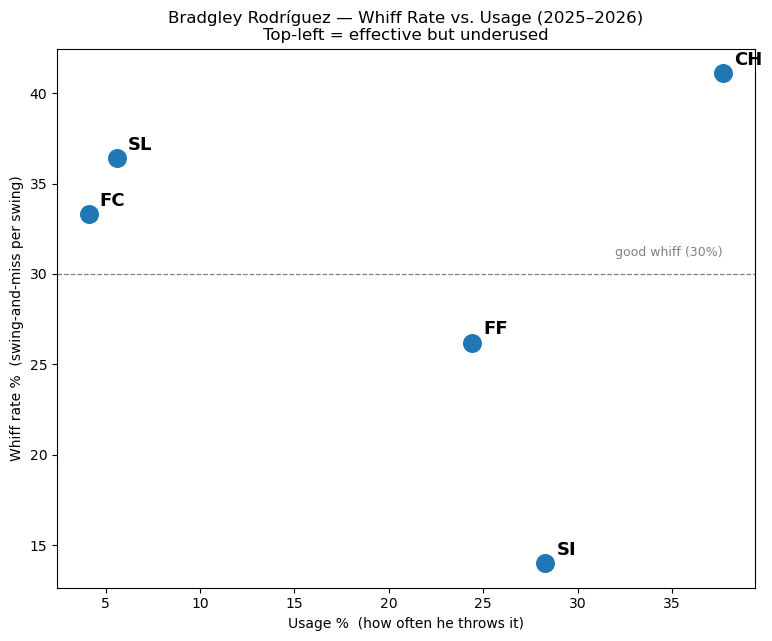

In [15]:
import matplotlib.pyplot as plt

plot_df = summary_all.reset_index()

plt.figure(figsize=(9, 7))
plt.scatter(plot_df["usage_%"], plot_df["whiff_rate"], s=160, color="#1f77b4")

# Label each pitch
for _, row in plot_df.iterrows():
    plt.annotate(
        row["pitch_type"],
        (row["usage_%"], row["whiff_rate"]),
        xytext=(8, 6), textcoords="offset points",
        fontsize=13, fontweight="bold"
    )

# Reference line for an "above-average whiff" pitch
plt.axhline(30, color="gray", linestyle="--", linewidth=0.9)
plt.text(plot_df["usage_%"].max(), 31, "good whiff (30%)", color="gray", ha="right", fontsize=9)

plt.xlabel("Usage %)
plt.ylabel("Whiff rate %)
plt.title("Bradgley Rodríguez — Whiff Rate vs. Usage (2025–2026)\nTop-left = effective but underused")
plt.show()

In [16]:
from pybaseball import playerid_lookup

info = playerid_lookup("buehler", "walker", fuzzy=True)
print(info[["name_first", "name_last", "key_mlbam", "mlb_played_first", "mlb_played_last"]])

  name_first name_last  key_mlbam  mlb_played_first  mlb_played_last
0     walker   buehler     621111            2017.0           2026.0


In [17]:
pid = int(info.iloc[0]["key_mlbam"])
print("Using ID:", pid)


Using ID: 621111


In [18]:
from pybaseball import statcast_pitcher
import pandas as pd

swing_events = ["foul", "hit_into_play", "swinging_strike", "swinging_strike_blocked", "foul_tip"]
whiff_events = ["swinging_strike", "swinging_strike_blocked", "foul_tip"]
strike_events = ["called_strike", "swinging_strike", "swinging_strike_blocked", "foul", "foul_tip", "hit_into_play"]

seasons = {
    2023: ("2023-03-01", "2023-11-01"),
    2024: ("2024-03-01", "2024-11-01"),
    2025: ("2025-03-01", "2025-11-01"),
    2026: ("2026-03-01", "2026-06-27"),
}

frames = []
for yr, (start, end) in seasons.items():
    df = statcast_pitcher(start, end, pid)
    if df is not None and len(df) > 0:
        df["year"] = yr
        frames.append(df)
        print(yr, "->", len(df), "pitches")
    else:
        print(yr, "-> no data")

allyears = pd.concat(frames, ignore_index=True)

allyears["is_swing"]  = allyears["description"].isin(swing_events)
allyears["is_whiff"]  = allyears["description"].isin(whiff_events)
allyears["is_strike"] = allyears["description"].isin(strike_events)

g = allyears.groupby("year").agg(
    pitches=("year", "count"),
    swings=("is_swing", "sum"),
    whiffs=("is_whiff", "sum"),
    strikes=("is_strike", "sum"),
)
g["whiff_rate"]  = (100 * g["whiffs"] / g["swings"]).round(1)
g["strike_rate"] = (100 * g["strikes"] / g["pitches"]).round(1)

# Average four-seam velocity by year (a key recovery signal for a post-surgery arm)
ff_velo = allyears[allyears["pitch_type"] == "FF"].groupby("year")["release_speed"].mean().round(1)
g["ff_velo"] = ff_velo

print(g[["pitches", "ff_velo", "whiff_rate", "strike_rate"]])

Gathering Player Data
2023 -> no data
Gathering Player Data
2024 -> 1599 pitches
Gathering Player Data
2025 -> 2330 pitches
Gathering Player Data
2026 -> 1572 pitches
      pitches  ff_velo  whiff_rate  strike_rate
year                                           
2024     1599     94.9        22.0         62.6
2025     2330     94.0        19.6         61.9
2026     1572     93.7        21.6         62.9


In [19]:
import pandas as pd
from pybaseball import statcast_pitcher, playerid_lookup

# get his id (reuse if you already have pid)
try:
    pid
except NameError:
    info = playerid_lookup("buehler", "walker", fuzzy=True)
    pid = int(info.iloc[0]["key_mlbam"])
print("Using ID:", pid)

pulls = {"2024": ("2024-03-01","2024-11-01"),
         "2025": ("2025-03-01","2025-11-01"),
         "2026": ("2026-03-01","2026-06-27")}

frames = []
for label,(s,e) in pulls.items():
    df = statcast_pitcher(s, e, pid)
    if df is not None and len(df) > 0:
        df["season"] = label
        frames.append(df)
        print(label, "->", len(df), "pitches")

buehler = pd.concat(frames, ignore_index=True)
buehler["game_date"] = pd.to_datetime(buehler["game_date"])
buehler["month"] = buehler["game_date"].dt.month

def period(row):
    if row["season"] == "2026":
        m = {3:"2026 Mar",4:"2026 Apr",5:"2026 May",6:"2026 Jun",7:"2026 Jul"}
        return m.get(row["month"], f"2026 m{row['month']}")
    return row["season"]

buehler["period"] = buehler.apply(period, axis=1)
print("done — periods:", sorted(buehler['period'].unique()))

Using ID: 621111
Gathering Player Data
2024 -> 1599 pitches
Gathering Player Data
2025 -> 2330 pitches
Gathering Player Data
2026 -> 1572 pitches
done — periods: ['2024', '2025', '2026 Apr', '2026 Jun', '2026 Mar', '2026 May']


In [20]:
swing_events  = ["foul","hit_into_play","swinging_strike","swinging_strike_blocked","foul_tip"]
whiff_events  = ["swinging_strike","swinging_strike_blocked","foul_tip"]
strike_events = ["called_strike","swinging_strike","swinging_strike_blocked","foul","foul_tip","hit_into_play"]

buehler["is_swing"]  = buehler["description"].isin(swing_events)
buehler["is_whiff"]  = buehler["description"].isin(whiff_events)
buehler["is_strike"] = buehler["description"].isin(strike_events)

order = ["2024","2025","2026 Mar","2026 Apr","2026 May","2026 Jun","2026 Jul"]

g = buehler.groupby("period").agg(
    pitches=("period","count"),
    swings=("is_swing","sum"),
    whiffs=("is_whiff","sum"),
    strikes=("is_strike","sum"),
)
g["whiff_rate"]  = (100*g["whiffs"]/g["swings"]).round(1)
g["strike_rate"] = (100*g["strikes"]/g["pitches"]).round(1)
g["ff_velo"] = buehler[buehler["pitch_type"]=="FF"].groupby("period")["release_speed"].mean().round(1)

g = g.reindex([p for p in order if p in g.index])
print(g[["pitches","ff_velo","whiff_rate","strike_rate"]])

          pitches  ff_velo  whiff_rate  strike_rate
period                                             
2024         1599     94.9        22.0         62.6
2025         2330     94.0        19.6         61.9
2026 Mar      343     92.5        28.2         63.3
2026 Apr      391     94.0        21.2         59.8
2026 May      415     93.9        17.4         63.9
2026 Jun      423     94.3        20.7         64.5


In [21]:
counts = buehler.groupby(["period","pitch_type"]).size().unstack(fill_value=0)
mix = counts.div(counts.sum(axis=1), axis=0).mul(100).round(1)
mix = mix.reindex([p for p in order if p in mix.index])
print(mix)

pitch_type    CH    FC    FF    KC    SI    SL    ST
period                                              
2024         4.6  20.1  30.2  19.5  15.0   1.0   9.6
2025         7.1  17.1  25.1  12.9  16.3  14.4   7.1
2026 Mar    18.4  16.0  19.2  14.6   8.2  11.1  12.5
2026 Apr     8.7  26.6  15.9  15.9  14.6  11.0   7.4
2026 May     6.7  22.4  22.9  11.3  21.2   7.0   8.4
2026 Jun     7.6  24.8  22.7   6.0  17.2  13.1   8.6


In [22]:
bip = buehler[buehler["type"] == "X"].copy()   # type "X" = ball in play
bip["hard_hit"] = bip["launch_speed"] >= 95

cq = bip.groupby("period").agg(
    balls_in_play=("type", "count"),
    avg_exit_velo=("launch_speed", "mean"),
    hard_hit=("hard_hit", "sum"),
    xwoba_contact=("estimated_woba_using_speedangle", "mean"),
)
cq["avg_exit_velo"]   = cq["avg_exit_velo"].round(1)
cq["hard_hit_rate"]   = (100 * cq["hard_hit"] / cq["balls_in_play"]).round(1)
cq["xwoba_contact"]   = cq["xwoba_contact"].round(3)

cq = cq.reindex([p for p in order if p in cq.index])
print(cq[["balls_in_play", "avg_exit_velo", "hard_hit_rate", "xwoba_contact"]])

          balls_in_play  avg_exit_velo  hard_hit_rate  xwoba_contact
period                                                              
2024                290           87.8           38.3          0.368
2025                426           87.6           36.9          0.376
2026 Mar             59           88.4           39.0          0.394
2026 Apr             63           91.2           39.7          0.385
2026 May             80           89.8           42.5          0.381
2026 Jun             73           91.2           42.5          0.355


In [23]:
rel = buehler.groupby(["season","pitch_type"]).agg(
    n=("pitch_type","count"),
    rel_side=("release_pos_x","mean"),
    rel_height=("release_pos_z","mean"),
    spin_axis=("spin_axis","mean"),
).round(2)

# only show pitches with a real sample
rel = rel[rel["n"] >= 30]
print(rel)

                     n  rel_side  rel_height  spin_axis
season pitch_type                                      
2024   CH           74     -1.38        5.43     230.09
       FC          321     -1.16        5.53     172.86
       FF          481     -1.12        5.60     203.39
       KC          311     -0.98        5.68      31.85
       SI          239     -1.45        5.36     212.97
       ST          153     -1.28        5.39      66.11
2025   CH          159     -1.53        5.38     239.06
       FC          386     -1.19        5.51     176.02
       FF          566     -1.17        5.56     206.23
       KC          291     -1.01        5.65      34.72
       SI          368     -1.53        5.28     218.54
       SL          324     -1.20        5.55     132.88
       ST          160     -1.30        5.32      71.12
2026   CH          157     -1.18        5.59     233.86
       FC          356     -1.13        5.60     173.01
       FF          318     -1.02        5.65    

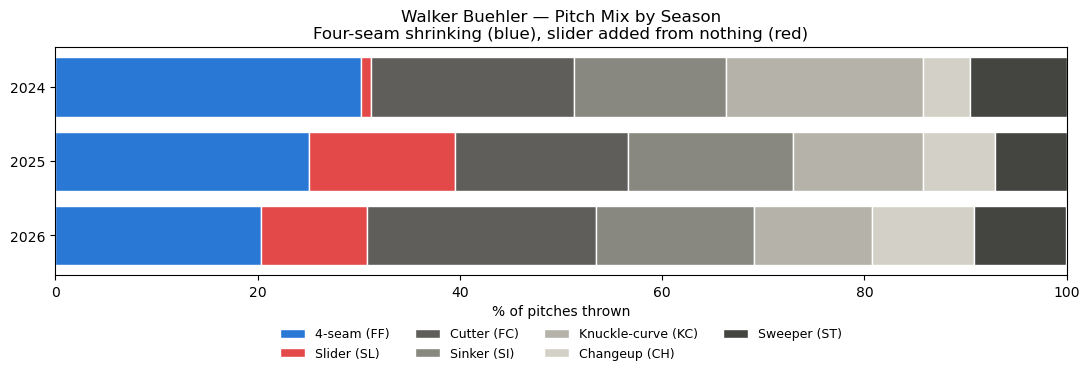

In [24]:
import matplotlib.pyplot as plt

# Seasons only (drop the monthly rows for the season-over-season story)
mix_seasons = mix.loc[[p for p in ["2024", "2025", "2026 Mar"] if p in mix.index]] if "2026 Mar" in mix.index else mix

# Build a clean 3-season table directly so the chart is exact
seasons = ["2024", "2025", "2026"]
data = {
    "FF": [30.2, 25.1, 20.3],   # four-seam
    "SL": [1.0, 14.4, 10.5],    # slider
    "FC": [20.1, 17.1, 22.7],   # cutter
    "SI": [15.0, 16.3, 15.6],   # sinker
    "KC": [19.5, 12.9, 11.7],   # knuckle-curve
    "CH": [4.6, 7.1, 10.0],     # changeup
    "ST": [9.6, 7.1, 9.1],      # sweeper
}

# Highlight FF (blue) and SL (red); everything else gray shades
colors = {
    "FF": "#2a78d6", "SL": "#e34948",
    "FC": "#5f5e5a", "SI": "#888780", "KC": "#b4b2a9",
    "CH": "#d3d1c7", "ST": "#444441",
}
labels = {
    "FF": "4-seam (FF)", "SL": "Slider (SL)", "FC": "Cutter (FC)",
    "SI": "Sinker (SI)", "KC": "Knuckle-curve (KC)", "CH": "Changeup (CH)", "ST": "Sweeper (ST)",
}

order = ["FF", "SL", "FC", "SI", "KC", "CH", "ST"]

fig, ax = plt.subplots(figsize=(11, 4))
left = [0, 0, 0]
for pitch in order:
    vals = data[pitch]
    ax.barh(seasons, vals, left=left, color=colors[pitch], label=labels[pitch], edgecolor="white")
    left = [l + v for l, v in zip(left, vals)]

ax.set_xlim(0, 100)
ax.set_xlabel("% of pitches thrown")
ax.set_title("Walker Buehler — Pitch Mix by Season\nFour-seam shrinking (blue), slider added from nothing (red)")
ax.invert_yaxis()  # 2024 on top, 2026 on bottom
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.18), frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

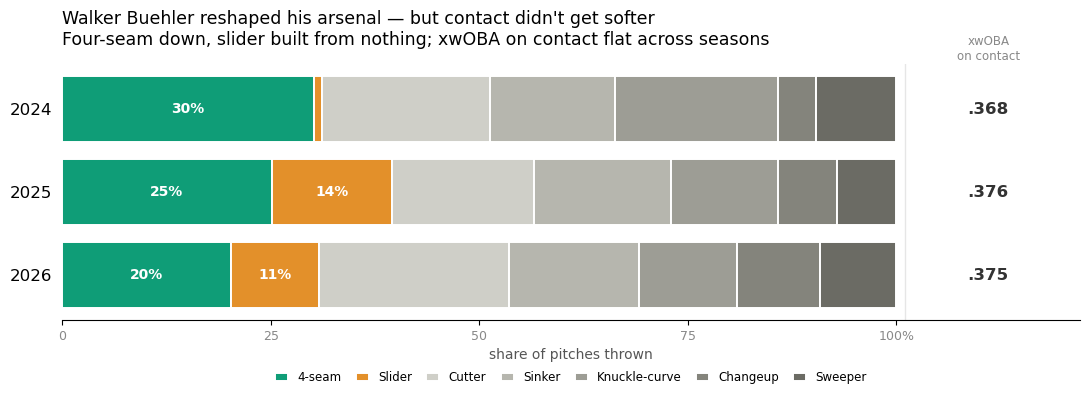

In [25]:
import matplotlib.pyplot as plt
import numpy as np

seasons = ["2024", "2025", "2026"]
order   = ["FF", "SL", "FC", "SI", "KC", "CH", "ST"]
label_map = {"FF":"4-seam", "SL":"Slider", "FC":"Cutter", "SI":"Sinker",
             "KC":"Knuckle-curve", "CH":"Changeup", "ST":"Sweeper"}

# --- pitch mix % per season, computed live ---
counts  = buehler.groupby(["season", "pitch_type"]).size().unstack(fill_value=0)
mix_pct = counts.div(counts.sum(axis=1), axis=0).mul(100).reindex(index=seasons)
for p in order:
    if p not in mix_pct.columns:
        mix_pct[p] = 0.0

# --- xwOBA on contact per season, computed live ---
bip   = buehler[buehler["type"] == "X"]
xwoba = bip.groupby("season")["estimated_woba_using_speedangle"].mean().reindex(seasons)

# --- colors: highlight FF (teal) + SL (amber), rest neutral grays ---
highlight = {"FF": "#0f9d77", "SL": "#e3902a"}
grays = ["#cfcfc8", "#b6b6ae", "#9d9d95", "#84847c", "#6b6b64"]
cmap, gi = {}, 0
for p in order:
    if p in highlight:
        cmap[p] = highlight[p]
    else:
        cmap[p] = grays[gi]; gi += 1

# --- plot ---
fig, ax = plt.subplots(figsize=(11, 4.2))
y, left = np.arange(len(seasons)), np.zeros(len(seasons))

for p in order:
    vals = mix_pct[p].values
    ax.barh(y, vals, left=left, color=cmap[p], edgecolor="white", linewidth=1.4, label=label_map[p])
    if p in highlight:  # label the two pitches that changed
        for yi, (l, v) in enumerate(zip(left, vals)):
            if v > 3:
                ax.text(l + v/2, yi, f"{v:.0f}%", ha="center", va="center",
                        color="white", fontsize=10, fontweight="bold")
    left += vals

# xwOBA-on-contact printed to the right of each bar
ax.axvline(101, color="#e6e6e6", lw=1)
for yi, s in enumerate(seasons):
    v = xwoba.loc[s]
    ax.text(111, yi, f".{int(round(v*1000)):03d}", ha="center", va="center",
            fontsize=12, fontweight="bold", color="#333")
ax.text(111, -0.72, "xwOBA\non contact", ha="center", va="center", fontsize=8.5, color="#888")

ax.set_xlim(0, 122)
ax.set_yticks(y); ax.set_yticklabels(seasons, fontsize=12)
ax.invert_yaxis()
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(["0", "25", "50", "75", "100%"], fontsize=9, color="#888")
ax.set_xlabel("share of pitches thrown", fontsize=10, color="#555")
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)

ax.set_title("Walker Buehler reshaped his arsenal — but contact didn't get softer\n"
             "Four-seam down, slider built from nothing; xwOBA on contact flat across seasons",
             fontsize=12.5, loc="left", pad=14)
ax.legend(ncol=7, loc="upper center", bbox_to_anchor=(0.5, -0.16),
          frameon=False, fontsize=8.5, handlelength=1.1, columnspacing=1.2)
plt.tight_layout()
plt.show()

In [26]:
ax.set_title("Walker Buehler — Pitch Mix and Contact Quality by Season (2024–2026)",
             fontsize=13, loc="left", pad=14, fontweight="bold")

Text(0.0, 1.0, 'Walker Buehler — Pitch Mix and Contact Quality by Season (2024–2026)')

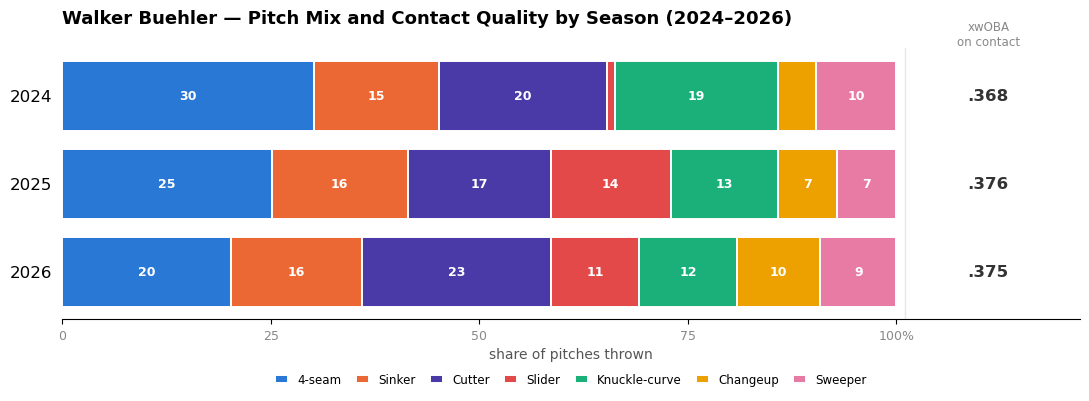

In [27]:
import matplotlib.pyplot as plt
import numpy as np

seasons = ["2024", "2025", "2026"]
order   = ["FF", "SI", "FC", "SL", "KC", "CH", "ST"]
label_map = {"FF":"4-seam", "SI":"Sinker", "FC":"Cutter", "SL":"Slider",
             "KC":"Knuckle-curve", "CH":"Changeup", "ST":"Sweeper"}

# shared palette (reused in chart 2 for a consistent house style)
cmap = {"FF":"#2a78d6", "SI":"#eb6834", "FC":"#4a3aa7", "SL":"#e34948",
        "KC":"#1baf7a", "CH":"#eda100", "ST":"#e87ba4"}

# pitch mix % per season (live)
counts  = buehler.groupby(["season","pitch_type"]).size().unstack(fill_value=0)
mix_pct = counts.div(counts.sum(axis=1), axis=0).mul(100).reindex(index=seasons)
for p in order:
    if p not in mix_pct.columns: mix_pct[p] = 0.0

# xwOBA on contact per season (live)
bip = buehler[buehler["type"] == "X"]
xwoba = bip.groupby("season")["estimated_woba_using_speedangle"].mean().reindex(seasons)

fig, ax = plt.subplots(figsize=(11, 4.2))
y, left = np.arange(len(seasons)), np.zeros(len(seasons))
for p in order:
    vals = mix_pct[p].values
    ax.barh(y, vals, left=left, color=cmap[p], edgecolor="white", linewidth=1.4, label=label_map[p])
    for yi,(l,v) in enumerate(zip(left, vals)):
        if v > 7:
            ax.text(l+v/2, yi, f"{v:.0f}", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    left += vals

# xwOBA column on the right
ax.axvline(101, color="#e6e6e6", lw=1)
for yi, s in enumerate(seasons):
    ax.text(111, yi, f".{int(round(xwoba.loc[s]*1000)):03d}", ha="center", va="center",
            fontsize=12, fontweight="bold", color="#333")
ax.text(111, -0.7, "xwOBA\non contact", ha="center", va="center", fontsize=8.5, color="#888")

ax.set_xlim(0, 122); ax.set_yticks(y); ax.set_yticklabels(seasons, fontsize=12); ax.invert_yaxis()
ax.set_xticks([0,25,50,75,100]); ax.set_xticklabels(["0","25","50","75","100%"], fontsize=9, color="#888")
ax.set_xlabel("share of pitches thrown", fontsize=10, color="#555")
for sp in ["top","right","left"]: ax.spines[sp].set_visible(False)
ax.tick_params(left=False)
ax.set_title("Walker Buehler — Pitch Mix and Contact Quality by Season (2024–2026)",
             fontsize=13, loc="left", pad=18, fontweight="bold")
ax.legend(ncol=7, loc="upper center", bbox_to_anchor=(0.5,-0.16), frameon=False,
          fontsize=8.5, handlelength=1.1, columnspacing=1.2)
plt.tight_layout(); plt.show()

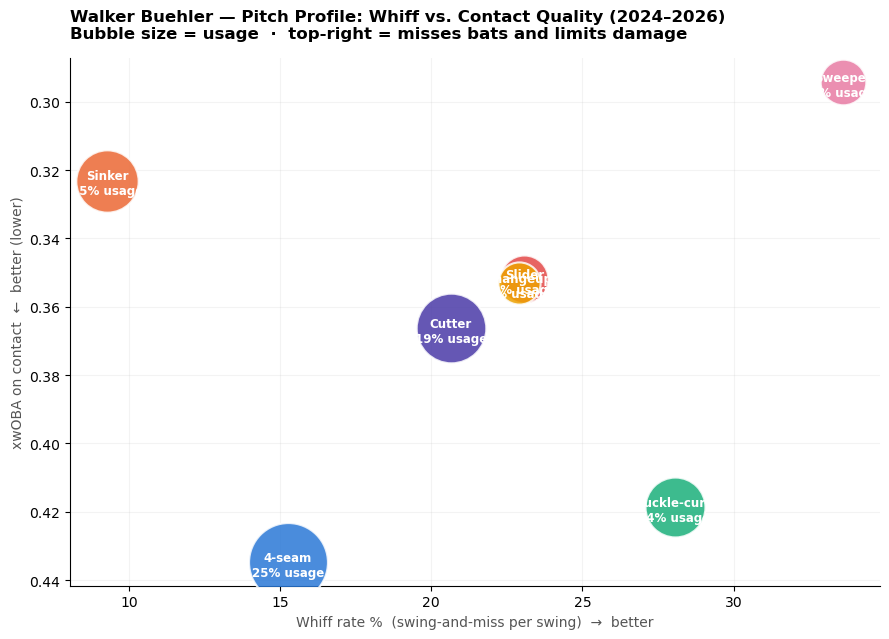

In [28]:
import matplotlib.pyplot as plt

# Per-pitch metrics across all three seasons (bigger sample = more stable)
b = buehler.copy()
swing_ev = ["foul","hit_into_play","swinging_strike","swinging_strike_blocked","foul_tip"]
whiff_ev = ["swinging_strike","swinging_strike_blocked","foul_tip"]
b["is_swing"] = b["description"].isin(swing_ev)
b["is_whiff"] = b["description"].isin(whiff_ev)

rows = []
for p in order:
    sub = b[b["pitch_type"] == p]
    if len(sub) < 30:   # skip tiny-sample pitches
        continue
    sw = sub["is_swing"].sum()
    whiff = 100 * sub["is_whiff"].sum() / sw if sw else 0
    xw = sub.loc[sub["type"]=="X", "estimated_woba_using_speedangle"].mean()
    usage = 100 * len(sub) / len(b)
    rows.append((p, whiff, xw, usage))

fig, ax = plt.subplots(figsize=(9, 6.5))
for p, whiff, xw, usage in rows:
    ax.scatter(whiff, xw, s=usage*130, color=cmap[p], alpha=0.85, edgecolor="white", linewidth=1.5, zorder=3)
    ax.annotate(f"{label_map[p]}\n{usage:.0f}% usage", (whiff, xw),
                xytext=(0, -2), textcoords="offset points", ha="center", va="center",
                fontsize=8.5, fontweight="bold", color="white", zorder=4)

ax.set_xlabel("Whiff rate %  (swing-and-miss per swing)  →  better", fontsize=10, color="#555")
ax.set_ylabel("xwOBA on contact  ←  better (lower)", fontsize=10, color="#555")
ax.invert_yaxis()  # better contact (low xwOBA) toward the top
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
ax.set_title("Walker Buehler — Pitch Profile: Whiff vs. Contact Quality (2024–2026)\n"
             "Bubble size = usage  ·  top-right = misses bats and limits damage",
             fontsize=12, loc="left", pad=14, fontweight="bold")
ax.grid(True, alpha=0.15)
plt.tight_layout(); plt.show()

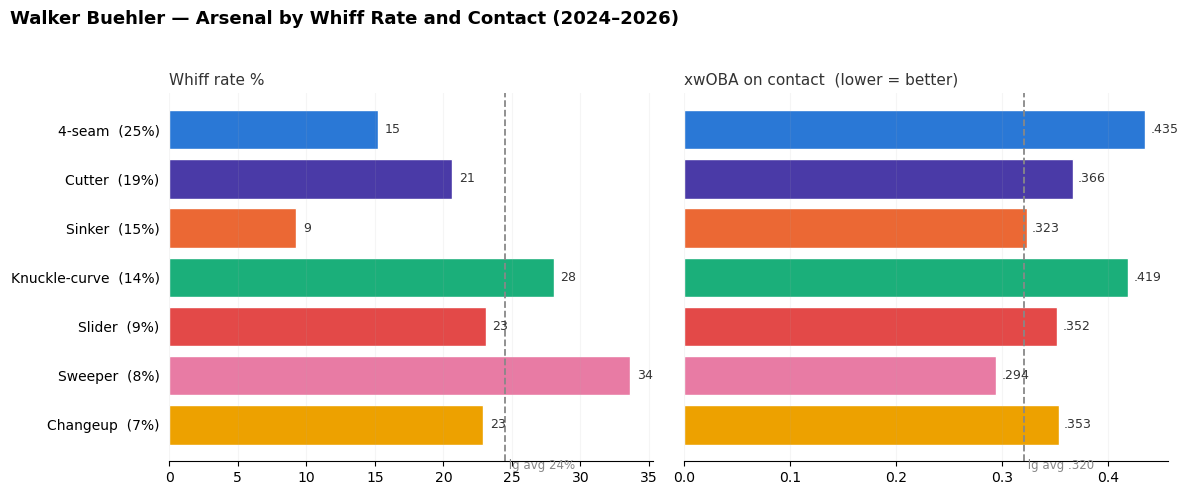

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# --- per-pitch metrics across 2024-2026 ---
b = buehler.copy()
swing_ev = ["foul","hit_into_play","swinging_strike","swinging_strike_blocked","foul_tip"]
whiff_ev = ["swinging_strike","swinging_strike_blocked","foul_tip"]
b["is_swing"] = b["description"].isin(swing_ev)
b["is_whiff"] = b["description"].isin(whiff_ev)

order = ["FF","SI","FC","SL","KC","CH","ST"]
label_map = {"FF":"4-seam","SI":"Sinker","FC":"Cutter","SL":"Slider",
             "KC":"Knuckle-curve","CH":"Changeup","ST":"Sweeper"}
cmap = {"FF":"#2a78d6","SI":"#eb6834","FC":"#4a3aa7","SL":"#e34948",
        "KC":"#1baf7a","CH":"#eda100","ST":"#e87ba4"}

rows = []
for p in order:
    sub = b[b["pitch_type"] == p]
    if len(sub) < 30: continue
    sw    = sub["is_swing"].sum()
    whiff = 100 * sub["is_whiff"].sum() / sw if sw else 0
    xw    = sub.loc[sub["type"]=="X", "estimated_woba_using_speedangle"].mean()
    usage = 100 * len(sub) / len(b)
    rows.append((p, whiff, xw, usage))

rows.sort(key=lambda r: r[3], reverse=True)   # most-used at top
labels = [f"{label_map[p]}  ({usage:.0f}%)" for p,_,_,usage in rows]
whiffs = [r[1] for r in rows]
xwobas = [r[2] for r in rows]
colors = [cmap[r[0]] for r in rows]
y = np.arange(len(rows))

# MLB-ish league averages (reference lines)
LG_WHIFF = 24.5     # ~league avg whiff rate %
LG_XWOBA = 0.320    # ~league avg xwOBA on contact

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ax1.barh(y, whiffs, color=colors, edgecolor="white")
ax1.axvline(LG_WHIFF, color="#888", ls="--", lw=1.3)
ax1.text(LG_WHIFF, len(rows)-0.3, f" lg avg {LG_WHIFF:.0f}%", color="#888", fontsize=8.5, va="top")
ax1.set_title("Whiff rate %", fontsize=11, loc="left", color="#333")
ax1.invert_yaxis()
for i,v in enumerate(whiffs):
    ax1.text(v+0.5, i, f"{v:.0f}", va="center", fontsize=9, color="#333")

ax2.barh(y, xwobas, color=colors, edgecolor="white")
ax2.axvline(LG_XWOBA, color="#888", ls="--", lw=1.3)
ax2.text(LG_XWOBA, len(rows)-0.3, f" lg avg .{int(LG_XWOBA*1000)}", color="#888", fontsize=8.5, va="top")
ax2.set_title("xwOBA on contact  (lower = better)", fontsize=11, loc="left", color="#333")
for i,v in enumerate(xwobas):
    ax2.text(v+0.005, i, f".{int(round(v*1000)):03d}", va="center", fontsize=9, color="#333")

ax1.set_yticks(y); ax1.set_yticklabels(labels, fontsize=10)
for ax in (ax1, ax2):
    for sp in ["top","right","left"]: ax.spines[sp].set_visible(False)
    ax.tick_params(left=False)
    ax.grid(axis="x", alpha=0.12)

fig.suptitle("Walker Buehler — Arsenal by Whiff Rate and Contact (2024–2026)",
             fontsize=13, x=0.012, ha="left", fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

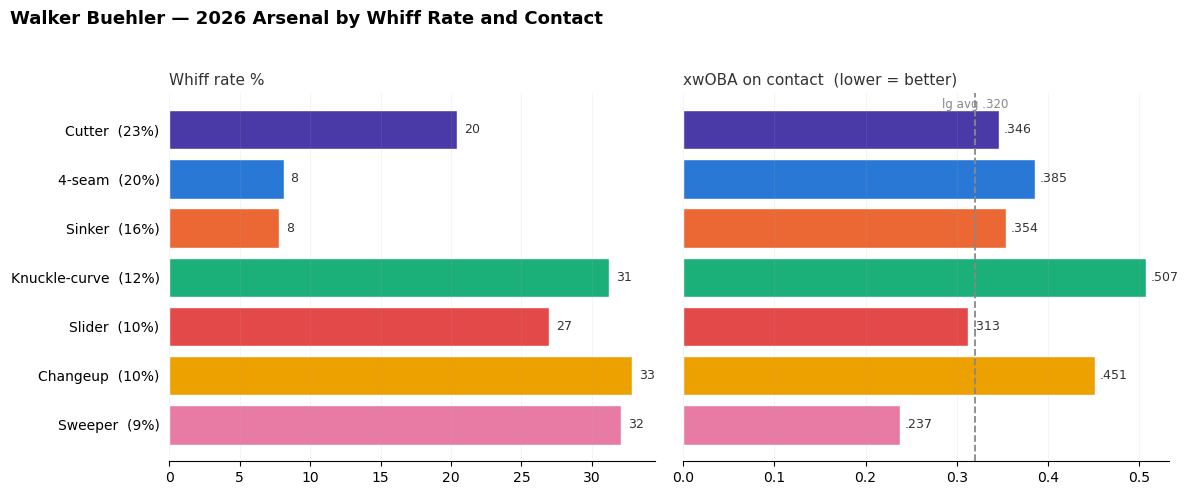

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# --- 2026 ONLY ---
b = buehler[buehler["season"] == "2026"].copy()
swing_ev = ["foul","hit_into_play","swinging_strike","swinging_strike_blocked","foul_tip"]
whiff_ev = ["swinging_strike","swinging_strike_blocked","foul_tip"]
b["is_swing"] = b["description"].isin(swing_ev)
b["is_whiff"] = b["description"].isin(whiff_ev)

order = ["FF","SI","FC","SL","KC","CH","ST"]
label_map = {"FF":"4-seam","SI":"Sinker","FC":"Cutter","SL":"Slider",
             "KC":"Knuckle-curve","CH":"Changeup","ST":"Sweeper"}
cmap = {"FF":"#2a78d6","SI":"#eb6834","FC":"#4a3aa7","SL":"#e34948",
        "KC":"#1baf7a","CH":"#eda100","ST":"#e87ba4"}

rows = []
for p in order:
    sub = b[b["pitch_type"] == p]
    if len(sub) < 20: continue          # 2026 is a partial season, lower floor
    sw    = sub["is_swing"].sum()
    whiff = 100 * sub["is_whiff"].sum() / sw if sw else 0
    xw    = sub.loc[sub["type"]=="X", "estimated_woba_using_speedangle"].mean()
    usage = 100 * len(sub) / len(b)
    rows.append((p, whiff, xw, usage))

rows.sort(key=lambda r: r[3], reverse=True)      # most-used at top
labels = [f"{label_map[p]}  ({usage:.0f}%)" for p,_,_,usage in rows]
whiffs = [r[1] for r in rows]
xwobas = [r[2] for r in rows]
colors = [cmap[r[0]] for r in rows]
y = np.arange(len(rows))

LG_XWOBA = 0.320     # approx. league avg xwOBA on contact

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Whiff panel (no league line)
ax1.barh(y, whiffs, color=colors, edgecolor="white")
ax1.set_title("Whiff rate %", fontsize=11, loc="left", color="#333")
ax1.invert_yaxis()
for i,v in enumerate(whiffs):
    ax1.text(v+0.5, i, f"{v:.0f}", va="center", fontsize=9, color="#333")

# xwOBA panel (league line here only)
ax2.barh(y, xwobas, color=colors, edgecolor="white")
ax2.axvline(LG_XWOBA, color="#888", ls="--", lw=1.3)
ax2.text(LG_XWOBA, -0.45, f"lg avg .{int(LG_XWOBA*1000)}", color="#888", fontsize=8.5, ha="center")
ax2.set_title("xwOBA on contact  (lower = better)", fontsize=11, loc="left", color="#333")
for i,v in enumerate(xwobas):
    ax2.text(v+0.005, i, f".{int(round(v*1000)):03d}", va="center", fontsize=9, color="#333")

ax1.set_yticks(y); ax1.set_yticklabels(labels, fontsize=10)
for ax in (ax1, ax2):
    for sp in ["top","right","left"]: ax.spines[sp].set_visible(False)
    ax.tick_params(left=False)
    ax.grid(axis="x", alpha=0.12)

fig.suptitle("Walker Buehler — 2026 Arsenal by Whiff Rate and Contact",
             fontsize=13, x=0.012, ha="left", fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

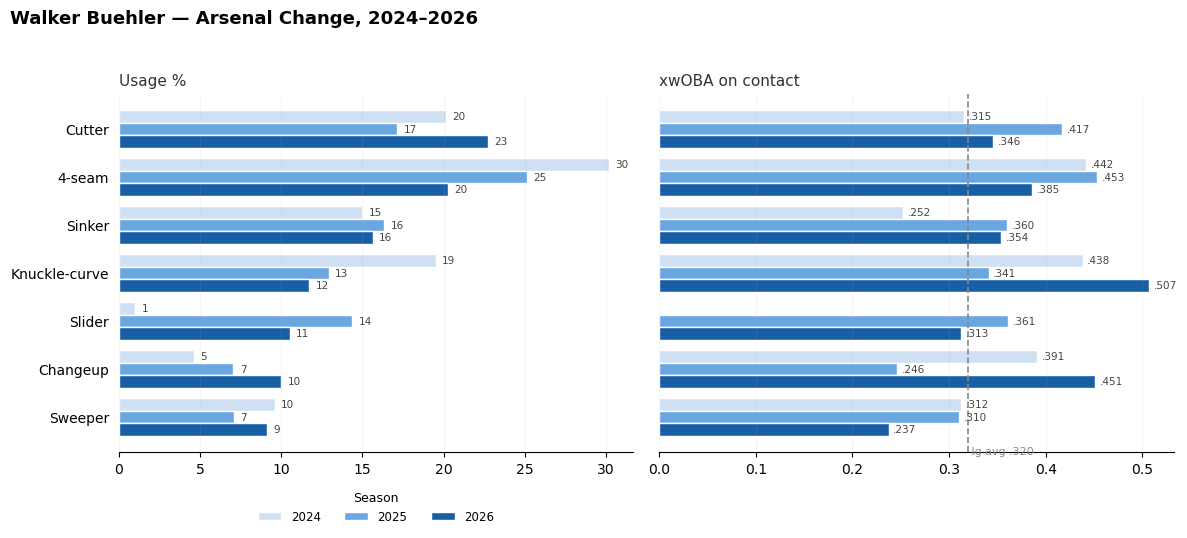

In [31]:
import matplotlib.pyplot as plt
import numpy as np

seasons = ["2024", "2025", "2026"]
season_color = {"2024": "#cfe0f3", "2025": "#6aa6e0", "2026": "#185fa5"}  # light→dark = older→newer

label_map = {"FF":"4-seam","SI":"Sinker","FC":"Cutter","SL":"Slider",
             "KC":"Knuckle-curve","CH":"Changeup","ST":"Sweeper"}

# --- usage % per pitch per season (live) ---
counts = buehler.groupby(["season","pitch_type"]).size().unstack(fill_value=0)
usage  = counts.div(counts.sum(axis=1), axis=0).mul(100)

# --- xwOBA on contact per pitch per season (live, min 10 BIP else blank) ---
bip = buehler[buehler["type"] == "X"]
xw_mean = bip.groupby(["season","pitch_type"])["estimated_woba_using_speedangle"].mean().unstack()
xw_n    = bip.groupby(["season","pitch_type"]).size().unstack(fill_value=0)
xw_mean = xw_mean.where(xw_n >= 10)   # hide tiny-sample pitch/season cells

# order pitches by 2026 usage
order = usage.loc["2026"].sort_values(ascending=False).index.tolist()
order = [p for p in order if p in label_map]
ylabels = [label_map[p] for p in order]
y = np.arange(len(order))
h = 0.26

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)

for i, s in enumerate(seasons):
    off = (i - 1) * h
    # usage panel
    uvals = [usage.loc[s, p] if p in usage.columns else 0 for p in order]
    ax1.barh(y + off, uvals, height=h, color=season_color[s], label=s, edgecolor="white")
    for yi, v in zip(y + off, uvals):
        if v > 0.5:
            ax1.text(v + 0.4, yi, f"{v:.0f}", va="center", fontsize=7.5, color="#444")
    # xwoba panel
    xvals = [xw_mean.loc[s, p] if (s in xw_mean.index and p in xw_mean.columns) else np.nan for p in order]
    ax2.barh(y + off, [0 if np.isnan(v) else v for v in xvals], height=h,
             color=season_color[s], edgecolor="white")
    for yi, v in zip(y + off, xvals):
        if not np.isnan(v):
            ax2.text(v + 0.005, yi, f".{int(round(v*1000)):03d}", va="center", fontsize=7.5, color="#444")

ax1.set_title("Usage %", fontsize=11, loc="left", color="#333")
ax2.set_title("xwOBA on contact", fontsize=11, loc="left", color="#333")
ax2.axvline(0.320, color="#888", ls="--", lw=1.2)
ax2.text(0.320, len(order)-0.4, " lg avg .320", color="#888", fontsize=8, va="top")

ax1.set_yticks(y); ax1.set_yticklabels(ylabels, fontsize=10)
ax1.invert_yaxis()
for ax in (ax1, ax2):
    for sp in ["top","right","left"]: ax.spines[sp].set_visible(False)
    ax.tick_params(left=False)
    ax.grid(axis="x", alpha=0.12)

ax1.legend(title="Season", ncol=3, fontsize=8.5, title_fontsize=9,
           loc="upper center", bbox_to_anchor=(0.5, -0.08), frameon=False)
fig.suptitle("Walker Buehler — Arsenal Change, 2024–2026",
             fontsize=13, x=0.012, ha="left", fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


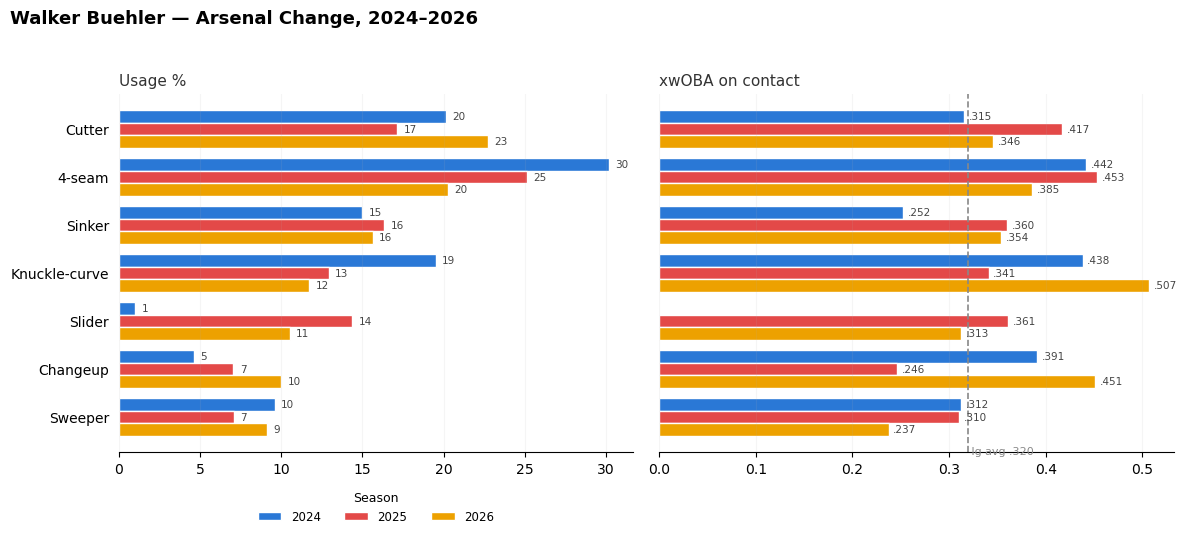

In [32]:
import matplotlib.pyplot as plt
import numpy as np

seasons = ["2024", "2025", "2026"]
season_color = {"2024": "#2a78d6", "2025": "#e34948", "2026": "#eda100"}  # blue / red / yellow

label_map = {"FF":"4-seam","SI":"Sinker","FC":"Cutter","SL":"Slider",
             "KC":"Knuckle-curve","CH":"Changeup","ST":"Sweeper"}

# --- usage % per pitch per season (live) ---
counts = buehler.groupby(["season","pitch_type"]).size().unstack(fill_value=0)
usage  = counts.div(counts.sum(axis=1), axis=0).mul(100)

# --- xwOBA on contact per pitch per season (live, min 10 BIP else blank) ---
bip = buehler[buehler["type"] == "X"]
xw_mean = bip.groupby(["season","pitch_type"])["estimated_woba_using_speedangle"].mean().unstack()
xw_n    = bip.groupby(["season","pitch_type"]).size().unstack(fill_value=0)
xw_mean = xw_mean.where(xw_n >= 10)   # hide tiny-sample pitch/season cells

# order pitches by 2026 usage
order = usage.loc["2026"].sort_values(ascending=False).index.tolist()
order = [p for p in order if p in label_map]
ylabels = [label_map[p] for p in order]
y = np.arange(len(order))
h = 0.26

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)

for i, s in enumerate(seasons):
    off = (i - 1) * h
    # usage panel
    uvals = [usage.loc[s, p] if p in usage.columns else 0 for p in order]
    ax1.barh(y + off, uvals, height=h, color=season_color[s], label=s, edgecolor="white")
    for yi, v in zip(y + off, uvals):
        if v > 0.5:
            ax1.text(v + 0.4, yi, f"{v:.0f}", va="center", fontsize=7.5, color="#444")
    # xwoba panel
    xvals = [xw_mean.loc[s, p] if (s in xw_mean.index and p in xw_mean.columns) else np.nan for p in order]
    ax2.barh(y + off, [0 if np.isnan(v) else v for v in xvals], height=h,
             color=season_color[s], edgecolor="white")
    for yi, v in zip(y + off, xvals):
        if not np.isnan(v):
            ax2.text(v + 0.005, yi, f".{int(round(v*1000)):03d}", va="center", fontsize=7.5, color="#444")

ax1.set_title("Usage %", fontsize=11, loc="left", color="#333")
ax2.set_title("xwOBA on contact", fontsize=11, loc="left", color="#333")
ax2.axvline(0.320, color="#888", ls="--", lw=1.2)
ax2.text(0.320, len(order)-0.4, " lg avg .320", color="#888", fontsize=8, va="top")

ax1.set_yticks(y); ax1.set_yticklabels(ylabels, fontsize=10)
ax1.invert_yaxis()
for ax in (ax1, ax2):
    for sp in ["top","right","left"]: ax.spines[sp].set_visible(False)
    ax.tick_params(left=False)
    ax.grid(axis="x", alpha=0.12)

ax1.legend(title="Season", ncol=3, fontsize=8.5, title_fontsize=9,
           loc="upper center", bbox_to_anchor=(0.5, -0.08), frameon=False)
fig.suptitle("Walker Buehler — Arsenal Change, 2024–2026",
             fontsize=13, x=0.012, ha="left", fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

In [33]:
import matplotlib.pyplot as plt

plot_df = summary_all.reset_index()

plt.figure(figsize=(9, 7))
plt.scatter(plot_df["usage_%"], plot_df["whiff_rate"], s=160, color="#1f77b4")

# Label each pitch
for _, row in plot_df.iterrows():
    plt.annotate(
        row["pitch_type"],
        (row["usage_%"], row["whiff_rate"]),
        xytext=(8, 6), textcoords="offset points",
        fontsize=13, fontweight="bold"
    )

# Reference line for an "above-average whiff" pitch
plt.axhline(30, color="gray", linestyle="--", linewidth=0.9)
plt.text(plot_df["usage
%"].max(), 31, "good whiff (30%)", color="gray", ha="right", fontsize=9)

plt.xlabel("Usage %)
plt.ylabel("Whiff rate %)
plt.title("Bradgley Rodríguez — Whiff Rate vs. Usage (2025–2026)\nTop-left = effective but underused")
plt.show()

SyntaxError: unterminated string literal (detected at line 21) (1877653880.py, line 21)